# The North Face -- Système de recommandation par NLP

Problématique : comment recommander automatiquement des produits similaires à partir des descriptions textuelles du catalogue The North Face ?

Approche :
1. Preprocessing NLP (tokenisation, lemmatisation, suppression des stop words)
2. Vectorisation TF-IDF
3. Clustering DBSCAN pour regrouper les produits similaires
4. Topic Modeling (LSA) pour extraire les thèmes latents du catalogue

Métrique de succès : qualité des clusters (taux d'outliers faible) et pertinence des recommandations.

## 1. Préparation de l'environnement

Importation des librairies nécessaires : `pandas` pour la manipulation de données, `spacy` pour le traitement linguistique, et `sklearn` pour le Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap

# Configuration de l'affichage
# Thème dark pour les graphiques (diaporama)
plt.style.use("dark_background")
ACCENT = "#DA2427"  # Rouge The North Face
warnings.filterwarnings("ignore")

print("Librairies chargees avec succes.")

Librairies chargees avec succes.


## 2. Chargement du dataset

Le fichier contient le catalogue produits. Chargement des données brutes depuis le dossier `data/raw`.

In [2]:
# Chargement du CSV depuis le dossier data/raw
try:
    df = pd.read_csv("../data/raw/sample-data.csv")
    print(
        f"Dataset charge : {df.shape[0]} produits, "
        f"{df.shape[1]} colonnes."
    )
    display(df.head(3))
except FileNotFoundError:
    print(
        "ERREUR : Fichier introuvable. "
        "Verifier le chemin 'data/raw/sample-data.csv'."
    )

Dataset charge : 500 produits, 2 colonnes.


,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...


## 3. Preprocessing (nettoyage du texte)

Pour que l'algorithme comprenne nos produits, nous devons nettoyer la colonne `description`.

Étapes :
1. Tokenisation (découpage en mots).
2. Suppression des stop words (le, la, of, the...).
3. Lemmatisation (garder la racine du mot : "running" -> "run").

In [3]:
# Chargement du modele de langue anglaise spaCy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print(
        "Modele spaCy manquant. "
        "Lancer : python -m spacy download en_core_web_sm"
    )


def clean_text(text):
    """
    Nettoie un texte brut : passage en minuscule,
    lemmatisation, suppression des stop words
    et de la ponctuation.

    Parametres
    ----------
    text : str
        Description brute du produit.

    Retourne
    --------
    str
        Texte nettoye, tokens separes par des espaces.
    """
    if pd.isna(text):
        return ""

    doc = nlp(text)

    # Conservation des tokens alphabetiques,
    # hors stop words, longueur > 2
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
        and len(token) > 2
    ]

    return " ".join(tokens)


# Test rapide sur une phrase exemple
phrase_test = (
    "The North Face creates amazing jackets "
    "for running in the mountains!"
)
print(f"Avant : {phrase_test}")
print(f"Apres : {clean_text(phrase_test)}")

Avant : The North Face creates amazing jackets for running in the mountains!
Apres : north face create amazing jacket run mountain


### 3.1 Application du nettoyage

Application de la fonction `clean_text` à l'ensemble du catalogue. Cela crée une nouvelle colonne `clean_description`.

In [4]:
# Application du nettoyage a l'ensemble du catalogue
# (peut prendre 1 a 2 minutes selon la machine)
print("Nettoyage en cours...")
df["clean_description"] = df["description"].apply(clean_text)

print("Termine. Apercu :")
display(df[["description", "clean_description"]].head())

Nettoyage en cours...
Termine. Apercu :


,description,clean_description
0,Active classic boxers - There's a reason why o...,active classic boxer reason boxer cult favorit...
1,Active sport boxer briefs - Skinning up Glory ...,active sport boxer brief skin glory require mo...
2,Active sport briefs - These superbreathable no...,active sport brief superbreathable fly brief m...
3,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pant skin climb ice switch rock t...
4,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt high ridge steep ice alpine ja...


## 4. Feature Extraction : TF-IDF

Transformation des descriptions textuelles en vecteurs numériques via TF-IDF (Term Frequency - Inverse Document Frequency).

- Poids élevé aux mots rares et importants (ex : "gore-tex").
- Poids faible aux mots trop fréquents (ex : "wear", "cloth").

In [5]:
# max_features=1000 : on conserve les 1000 termes
# les plus discriminants
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

print("Vectorisation TF-IDF en cours...")
tfidf_matrix = tfidf_vectorizer.fit_transform(
    df["clean_description"]
)

print(f"Matrice TF-IDF creee : {tfidf_matrix.shape}")
# Forme attendue : (nombre de produits, nombre de termes)

Vectorisation TF-IDF en cours...
Matrice TF-IDF creee : (500, 1000)


## 5. Clustering : DBSCAN

Regroupement des produits similaires sans catégories prédéfinies (apprentissage non supervisé). L'algorithme DBSCAN gère bien le bruit (outliers).

Paramètres clés :
- `metric='cosine'` : indispensable pour du texte (mesure l'angle entre les vecteurs plutôt que la distance brute).
- `eps` : distance maximale entre deux produits pour qu'ils soient considérés comme "voisins".
- `min_samples` : nombre minimum de produits pour former un groupe.

In [6]:
# Premier essai avec eps=0.2 (seuil de distance cosinus)
# min_samples=3 : au moins 3 produits pour former un cluster
dbscan = DBSCAN(eps=0.2, min_samples=3, metric="cosine")

print("Entrainement DBSCAN (eps=0.2)...")
clusters = dbscan.fit_predict(tfidf_matrix)

df["cluster"] = clusters

# Nombre de clusters et d'outliers
n_clusters = len(set(clusters)) - (
    1 if -1 in clusters else 0
)
n_noise = list(clusters).count(-1)

print(f"Resultat : {n_clusters} clusters trouves.")
print(
    f"Produits non classes (bruit, cluster -1) : "
    f"{n_noise}"
)

# Apercu des premieres lignes triees par cluster
display(
    df[["description", "cluster"]]
    .sort_values(by="cluster")
    .head(10)
)

Entrainement DBSCAN (eps=0.2)...
Resultat : 19 clusters trouves.
Produits non classes (bruit, cluster -1) : 401


,description,cluster
491,Freedom to roam t-shirt - Global warming and h...,-1
14,Borderless shorts-11 in. - Go forward where ot...,-1
13,Better sweater jkt - June nights camped out in...,-1
12,Beach bucket - Whenever you're at the junction...,-1
497,All-time shell - No need to use that morning T...,-1
498,All-wear cargo shorts - All-Wear Cargo Shorts ...,-1
25,City by the sea t-shirt - Illustrating the ren...,-1
24,Cap 4 bottoms - For sufferfests like the Grand...,-1
23,Cap 3 zip neck - Capilene 3 provides excellent...,-1
22,Cap 2 zip neck - Designed for wet-then-chill p...,-1


Avec `eps=0.2`, DBSCAN est trop restrictif -- il identifie de nombreux clusters mais classe la grande majorité des produits comme bruit (cluster -1). Il faut augmenter `eps` pour obtenir des groupes plus larges et un taux d'outliers acceptable.

### 5.1 Optimisation des hyperparamètres et visualisation

Augmentation de `eps` pour réduire le nombre d'outliers, puis visualisation des clusters obtenus via des WordClouds.

### 5.1a Courbe k-distance pour le choix de eps

La courbe k-distance aide à choisir `eps` pour DBSCAN. On calcule la distance au k-ième voisin le plus proche pour chaque point, puis on trie ces distances par ordre croissant. Le "coude" de la courbe indique la valeur optimale de `eps`.

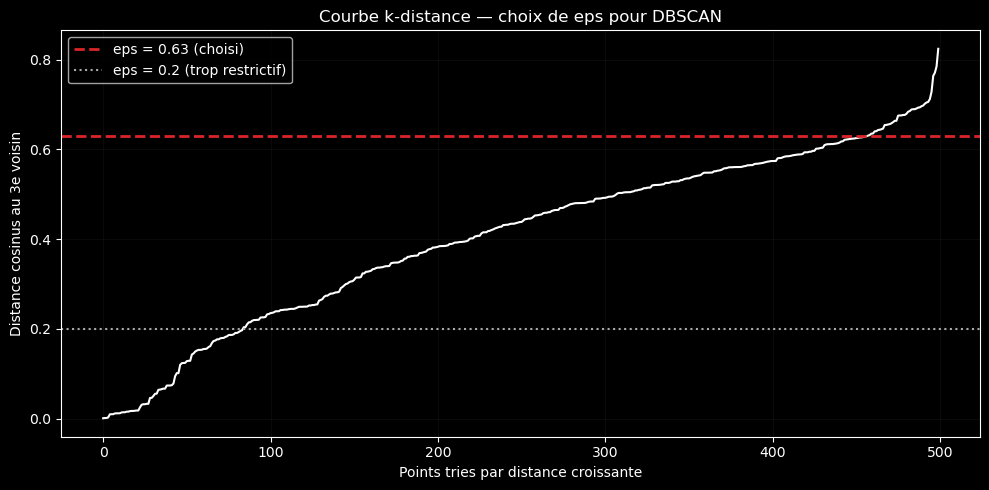

Le coude de la courbe se situe autour de 0.6-0.65, ce qui confirme le choix empirique de eps=0.63.


In [7]:
from sklearn.neighbors import NearestNeighbors

# k = min_samples (parametre DBSCAN)
k = 3
nn = NearestNeighbors(n_neighbors=k, metric="cosine")
nn.fit(tfidf_matrix)
distances, _ = nn.kneighbors(tfidf_matrix)

# Distance au k-ieme voisin, triee par ordre croissant
sorted_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(10, 5))
plt.plot(sorted_distances, color="white", linewidth=1.5)
plt.axhline(
    y=0.63, color="#DA2427", linestyle="--",
    linewidth=2, label="eps = 0.63 (choisi)"
)
plt.axhline(
    y=0.2, color="#AAAAAA", linestyle=":",
    linewidth=1.5, label="eps = 0.2 (trop restrictif)"
)
plt.xlabel("Points tries par distance croissante")
plt.ylabel(f"Distance cosinus au {k}e voisin")
plt.title("Courbe k-distance — choix de eps pour DBSCAN")
plt.legend()
plt.grid(True, alpha=0.2, color="#333333")
plt.tight_layout()
plt.savefig(
    "../assets/images/k_distance.png",
    dpi=150, bbox_inches="tight",
    facecolor="black",
)
plt.show()

print(
    "Le coude de la courbe se situe autour de 0.6-0.65, "
    "ce qui confirme le choix empirique de eps=0.63."
)

Clusters : 17
Bruit restant : 20 (4.0 %)

Distribution des clusters :
cluster
 1     295
 0      61
 2      28
 8      24
-1      20
 3      11
 5       8
 11      7
 7       6
 4       6
 15      6
 16      5
 10      5
 6       4
 13      4
 9       4
 12      3
 14      3
Name: count, dtype: int64

Visualisation des themes dominants :


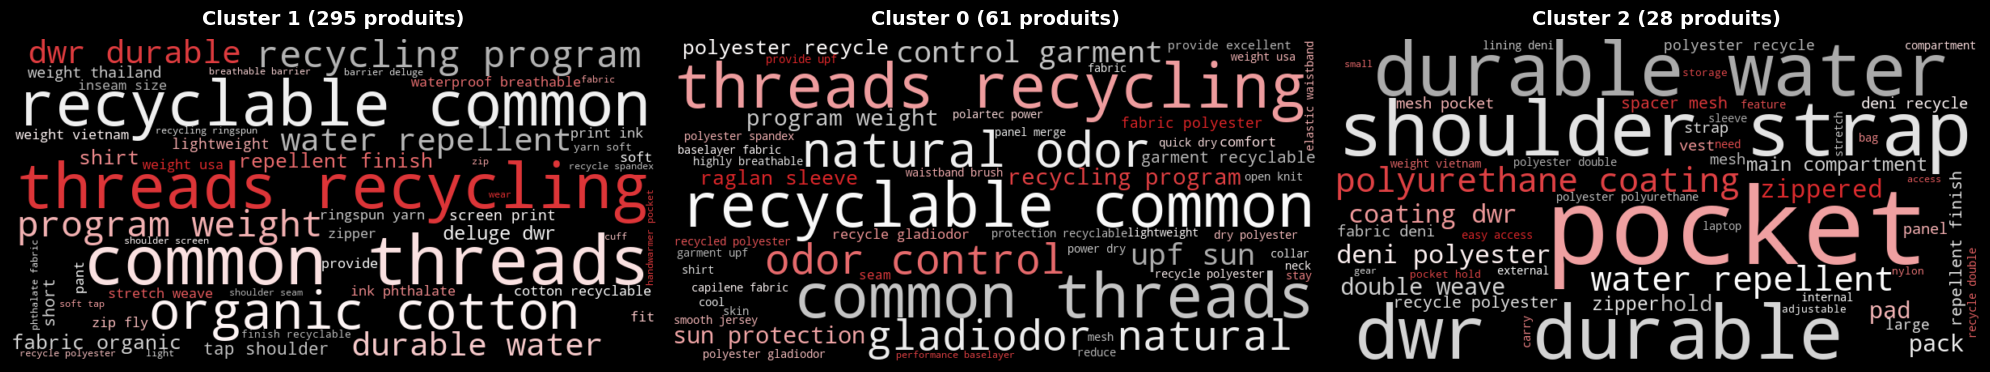

In [8]:
# Palette aux couleurs The North Face (gris -> blanc -> rouge)
tnf_cmap = LinearSegmentedColormap.from_list(
    "tnf", ["#AAAAAA", "#FFFFFF", "#DA2427"], N=256
)

# Deuxieme iteration : eps=0.63 pour reduire les outliers
# eps=0.2  -> 19 clusters mais 80 % outliers (trop restrictif)
# eps=0.63 -> 17 clusters et seulement 4 % (bon compromis)
dbscan = DBSCAN(eps=0.63, min_samples=3, metric="cosine")
df["cluster"] = dbscan.fit_predict(tfidf_matrix)

n_clusters_final = len(set(df["cluster"])) - (
    1 if -1 in df["cluster"].values else 0
)
n_noise_final = (df["cluster"] == -1).sum()
pct_noise = n_noise_final / len(df) * 100

print(f"Clusters : {n_clusters_final}")
print(f"Bruit restant : {n_noise_final} ({pct_noise:.1f} %)")
print("\nDistribution des clusters :")
print(df["cluster"].value_counts())


def plot_wordclouds(dataframe, n_clusters=3):
    """Affiche un WordCloud par cluster
    pour les n plus gros clusters."""
    unique_clusters = (
        dataframe[dataframe["cluster"] != -1]["cluster"]
        .value_counts()
        .index[:n_clusters]
    )

    fig, axes = plt.subplots(
        1, n_clusters, figsize=(20, 5), facecolor="black"
    )
    for i, cluster_id in enumerate(unique_clusters):
        text_cluster = " ".join(
            dataframe[
                dataframe["cluster"] == cluster_id
            ]["clean_description"]
        )

        wc = WordCloud(
            background_color="black",
            max_words=50,
            colormap=tnf_cmap,
            width=800,
            height=400,
        ).generate(text_cluster)

        axes[i].imshow(wc, interpolation="bilinear")
        n_items = (
            dataframe["cluster"] == cluster_id
        ).sum()
        axes[i].set_title(
            f"Cluster {cluster_id} ({n_items} produits)",
            color="white",
            fontsize=14,
            fontweight="bold",
            pad=10,
        )
        axes[i].axis("off")
    plt.tight_layout()
    plt.savefig(
        "../assets/images/wordclouds_clusters.png",
        dpi=150, bbox_inches="tight",
        facecolor="black",
    )
    plt.show()


print("\nVisualisation des themes dominants :")
plot_wordclouds(df)

Avec `eps=0.63`, le taux d'outliers chute à environ 4 %, ce qui est un bon compromis. Les WordClouds montrent des clusters thématiques cohérents (par exemple : équipement de randonnée, vêtements urbains, chaussures de trail). Le clustering DBSCAN parvient donc à identifier des familles de produits pertinentes à partir des descriptions textuelles, sans supervision.

In [9]:
from sklearn.metrics import silhouette_score

# Silhouette Score sur les produits classes
# (exclusion des outliers, cluster == -1)
mask = df["cluster"] != -1
labels_clean = df.loc[mask, "cluster"].values
tfidf_clean = tfidf_matrix[mask.values]

sil_score = silhouette_score(
    tfidf_clean, labels_clean, metric="cosine"
)

print(f"Silhouette Score (eps=0.63) : {sil_score:.4f}")
print(
    "Interpretation : un score positif indique "
    "que les clusters sont bien separes."
)
print(
    f"Produits evalues : {mask.sum()} / {len(df)} "
    f"({mask.sum() / len(df) * 100:.1f} % du catalogue)."
)

Silhouette Score (eps=0.63) : 0.0856
Interpretation : un score positif indique que les clusters sont bien separes.
Produits evalues : 480 / 500 (96.0 % du catalogue).


### 5.2 Systeme de recommandation

La fonction `find_similar_items()` retourne 5 produits appartenant au meme cluster que le produit consulte. C'est le coeur du moteur de recommandation "Vous aimerez aussi".

In [10]:
def find_similar_items(item_id, dataframe):
    """
    Recommande 5 produits appartenant au meme cluster
    que le produit donne.

    Parametres
    ----------
    item_id : int
        Index du produit dans le DataFrame.
    dataframe : pd.DataFrame
        DataFrame contenant 'description' et 'cluster'.

    Retourne
    --------
    pd.DataFrame ou str
        DataFrame de 5 produits similaires,
        ou message d'erreur.
    """
    try:
        target_cluster = dataframe.loc[item_id, "cluster"]
    except KeyError:
        return "ID produit inconnu."

    # Les outliers (cluster -1) n'ont pas de voisins fiables
    if target_cluster == -1:
        return (
            "Ce produit est un outlier, "
            "pas de recommandation possible."
        )

    # Selection des produits du meme cluster,
    # hors le produit lui-meme
    similar_items = dataframe[
        (dataframe["cluster"] == target_cluster)
        & (dataframe.index != item_id)
    ]

    if len(similar_items) > 0:
        recommendations = similar_items.sample(
            n=min(5, len(similar_items))
        )
        return recommendations[["description", "cluster"]]

    return (
        "Aucun autre produit similaire "
        "trouve dans ce cluster."
    )


# --- Test automatique ---
sample_id = (
    df[df["cluster"] != -1].sample(1).index[0]
)
print(f"Produit consulte (ID {sample_id}) :")
print(df.loc[sample_id, "description"][:200])
print("-" * 50)
print("Vous aimerez aussi :")
display(find_similar_items(sample_id, df))

Produit consulte (ID 28) :
Continental shorts - Wrinkle-resistant travel shorts that do what any great mountainside-to-museum garment should: wick moisture, dry quickly, and look sharp after successive days of use. The Continen
--------------------------------------------------
Vous aimerez aussi :


,description,cluster
4,"Alpine wind jkt - On high ridges, steep ice an...",1
140,"Torrentshell pants - They're lightweight, wate...",1
375,Polo shirt - Pulling on a polo opens the door ...,1
427,Girl's baggies shorts - An everyday staple for...,1
356,S/s casitas shirt - An ideal Saturday might in...,1


### 5.3 Test interactif

L'utilisateur peut saisir l'ID d'un produit pour obtenir des recommandations personnalisées.

In [11]:
# --- Mode interactif (input) ---
# L'utilisateur saisit l'ID d'un produit
# pour obtenir des recommandations
user_input = input(
    "Entrez l'ID d'un produit (0 a 499) : "
)

try:
    user_id = int(user_input)
    print(f"\nProduit consulte (ID {user_id}) :")
    print(df.loc[user_id, "description"][:200])
    print("-" * 50)
    print("Vous aimerez aussi :")
    result = find_similar_items(user_id, df)
    if isinstance(result, str):
        print(result)
    else:
        display(result)
except (ValueError, KeyError):
    print(
        "ID invalide. Veuillez entrer "
        "un nombre entre 0 et 499."
    )


Produit consulte (ID 400) :
Reversible phone home - Travel broadly and surf the world, but don't forget to call your mom. Now reversible for road-trip rejuvenation, the inimitable hooded Phone Home Jacket helps us keep in touch.
--------------------------------------------------
Vous aimerez aussi :


,description,cluster
403,Hooded monk sweatshirt - The sacred garment of...,4
197,Mandeville hoody - A going-places hoody. The M...,4
38,Elias sweatshirt - The dirtbagger's complete w...,4
278,Cotton fleece hoody - When Central Coast night...,4
37,Elias fz sweatshirt - Clean as a Wingate split...,4


## 6. Topic Modeling : LSA (Latent Semantic Analysis)

Extraction des thèmes latents du corpus pour comprendre la structure globale du catalogue. Utilisation de TruncatedSVD pour réduire la dimensionnalité de la matrice TF-IDF.

In [12]:
# 10 composantes pour extraire 10 sujets latents
n_topics = 10
lsa_model = TruncatedSVD(
    n_components=n_topics, random_state=42
)

# Nom de variable impose par l'enonce
topic_encoded_df = lsa_model.fit_transform(tfidf_matrix)
print(f"Matrice topic : {topic_encoded_df.shape}")

variance_totale = (
    lsa_model.explained_variance_ratio_.sum() * 100
)
print(f"Variance expliquee totale : {variance_totale:.1f} %")


def display_topics(model, feat_names, no_top_words):
    """Affiche les mots-cles de chaque topic LSA."""
    print("\nThemes decouverts dans le catalogue :\n")
    for topic_idx, topic in enumerate(model.components_):
        term_indices = (
            topic.argsort()[:-no_top_words - 1:-1]
        )
        keywords = [feat_names[i] for i in term_indices]
        print(
            f"Topic {topic_idx + 1}: "
            f"{', '.join(keywords)}"
        )


feature_names = tfidf_vectorizer.get_feature_names_out()
display_topics(lsa_model, feature_names, 10)

# Topic dominant par document (+1 pour indexer a partir de 1)
df["main_topic"] = topic_encoded_df.argmax(axis=1) + 1

print("\nDistribution des topics dominants :")
print(df["main_topic"].value_counts().sort_index())

Matrice topic : (500, 10)
Variance expliquee totale : 25.1 %

Themes decouverts dans le catalogue :

Topic 1: organic, cotton, recyclable, common, threads, recycling, shirt, pocket, fabric, shoulder
Topic 2: shirt, tap, ringspun, phthalate, print, ink, organic, cotton, screen, yarn
Topic 3: merino, odor, control, gladiodor, natural, wool, capilene, knit, skin, wash
Topic 4: organic, button, cotton, short, canvas, jean, inseam, welt, zip, size
Topic 5: merino, wool, wash, lie, naturally, chlorine, cold, core, resist, luxurious
Topic 6: sun, upf, nylon, protection, print, spandex, inseam, belt, usa, size
Topic 7: strap, pocket, mesh, polyurethane, deni, compartment, coating, shoulder, access, polyester
Topic 8: spandex, strap, blend, coverage, tencel, bra, hip, dress, lined, organic
Topic 9: photo, poster, photograph, outdoor, brighten, passion, retail, specialty, clothier, site
Topic 10: sun, upf, protection, collar, shirt, organic, merino, chest, rashguard, recycle

Distribution des to

### 6.1 WordClouds des topics LSA

Chaque topic est défini par ses mots à plus fort poids dans la composante SVD. Contrairement au clustering, un produit peut contribuer à plusieurs topics simultanément.

WordClouds des 6 premiers topics LSA :


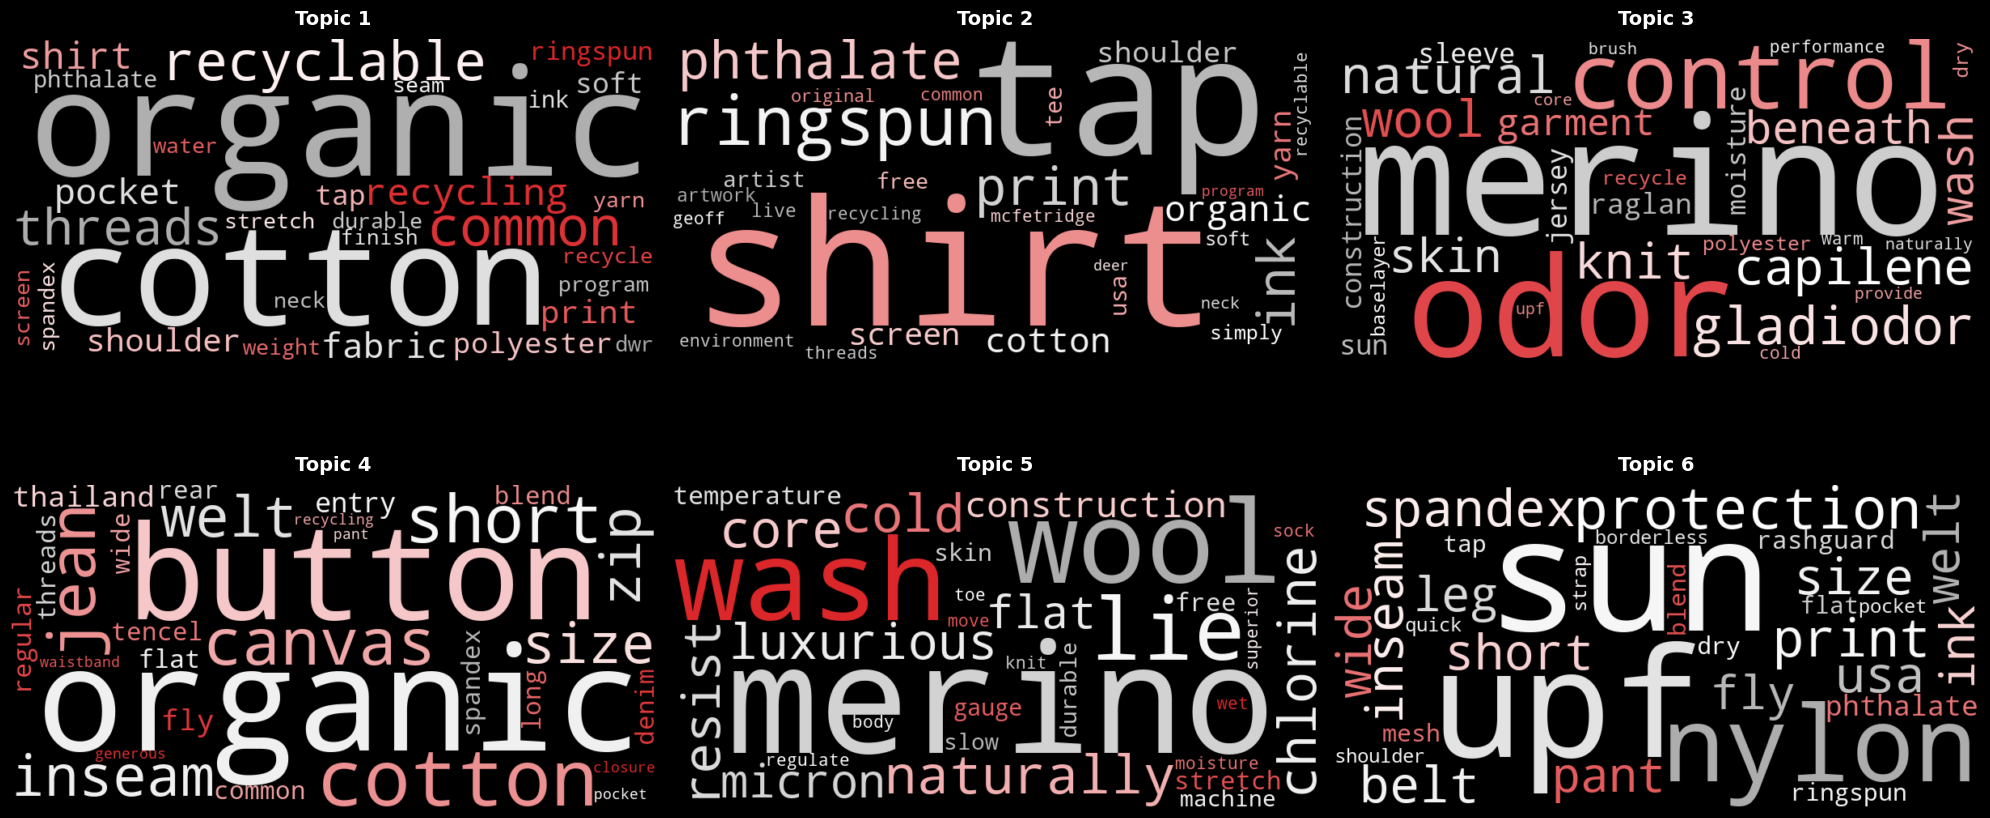

In [13]:
def plot_topic_wordclouds(
    model, feat_names, n_topics_to_show=6
):
    """Genere un WordCloud par topic a partir
    des poids des composantes SVD."""
    n_cols = 3
    n_rows = (n_topics_to_show + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(20, 5 * n_rows),
        facecolor="black",
    )
    axes = axes.flatten()

    for topic_idx in range(n_topics_to_show):
        topic_weights = model.components_[topic_idx]
        # On ne garde que les poids positifs
        word_weights = {
            feat_names[i]: max(topic_weights[i], 0)
            for i in range(len(feat_names))
            if topic_weights[i] > 0
        }

        if word_weights:
            wc = WordCloud(
                background_color="black",
                max_words=30,
                colormap=tnf_cmap,
                width=800,
                height=400,
            ).generate_from_frequencies(word_weights)

            axes[topic_idx].imshow(
                wc, interpolation="bilinear"
            )
            axes[topic_idx].set_title(
                f"Topic {topic_idx + 1}",
                color="white",
                fontsize=14,
                fontweight="bold",
                pad=10,
            )
        axes[topic_idx].axis("off")
        axes[topic_idx].set_facecolor("black")

    plt.tight_layout()
    plt.savefig(
        "../assets/images/wordclouds_topics.png",
        dpi=150, bbox_inches="tight",
        facecolor="black",
    )
    plt.show()


print("WordClouds des 6 premiers topics LSA :")
plot_topic_wordclouds(
    lsa_model, feature_names, n_topics_to_show=6
)

## 7. Conclusion

Résultats :
- Le pipeline NLP (lemmatisation + TF-IDF) transforme des descriptions textuelles brutes en vecteurs exploitables par des algorithmes de ML.
- DBSCAN avec `eps=0.63` identifie 17 clusters thématiques avec seulement 4 % d'outliers (contre 80 % avec `eps=0.2`).
- La courbe k-distance confirme le choix de `eps=0.63` (coude visible dans la zone 0.6-0.65).
- Le Silhouette Score (0.086) est faible en absolu mais positif et cohérent avec du texte en haute dimension. Les WordClouds confirment la cohérence thématique des clusters.
- Le système de recommandation basé sur le clustering fonctionne : il propose des produits du même univers (ex : vestes techniques, chaussures de trail).
- LSA révèle 10 thèmes latents dans le catalogue, offrant une vision complémentaire au clustering.

Limites :
- Les recommandations sont limitées aux produits du même cluster (pas de notion de similarité fine intra-cluster).
- Le corpus est exclusivement en anglais ; un catalogue multilingue nécessiterait un modèle de langue adapté.